In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Initialization and Dataset overview

In [ ]:
# @title
# ====================================================
# ML MODELS FOR DETERMINANTS OF CHILD ENROLLMENT
# Using Standardized Data - Google Colab Version
# ====================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Install necessary packages
!pip install pandas numpy scikit-learn statsmodels matplotlib seaborn

# ====================================================
# 1. LOAD DATA
# ====================================================
# Load the data
df = pd.read_csv('/content/done.csv')  # Adjust path

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# ====================================================
# 2. DATA PREPARATION
# ====================================================

# Define target variable
df['enrollment'] = df['going_school']  # Using going_school as primary target

# Check target distribution
print("\n=== Enrollment Distribution ===")
print(df['enrollment'].value_counts(normalize=True) * 100)
print(f"Enrollment rate: {df['enrollment'].mean()*100:.2f}%")

# Remove observations with missing target
df = df.dropna(subset=['enrollment'])
print(f"Data after removing missing target: {df.shape}")

# ====================================================
# 3. DEFINE FEATURE SETS
# ====================================================

# A. Continuous features (standardized)
cont_features = ['wealth_index_std', 'head_age_std', 'child_age_std', 'hh_members_std']

# B. Binary features
binary_features = ['hygiene', 'electricity', 'internet', 'house_owner', 'bike_owner',
                   'car_owner', 'health_insurance', 'computer', 'bank_account']

# C. Categorical features (to be one-hot encoded)
cat_features = ['mother_edu', 'head_edu', 'child_edu_lvl', 'urban_rural',
                'headgender', 'wealth_group', 'wealth_decile']

# D. Household resources
resource_features = ['vehicle_index_std', 'vehicle_count_std', 'vehicle_wealth_std']

# E. Child-specific features
child_features = ['child_rank', 'child_age_group']

# Combine all features
all_features = cont_features + binary_features + cat_features + resource_features + child_features

# Keep only features that exist in the dataframe
existing_features = [f for f in all_features if f in df.columns]
print(f"\nUsing {len(existing_features)} features from {len(all_features)} specified")

# ====================================================
# 4. HANDLE MISSING VALUES
# ====================================================

# Fill missing values (simple approach - adjust as needed)
for feature in existing_features:
    if df[feature].dtype in ['float64', 'int64']:
        df[feature] = df[feature].fillna(df[feature].median())
    else:
        df[feature] = df[feature].fillna(df[feature].mode()[0] if not df[feature].mode().empty else 0)

print(f"Missing values after imputation: {df[existing_features + ['enrollment']].isnull().sum().sum()}")

Dataset shape: (65985, 62)

First few rows:
   P_code  HH1  HH2  hygiene  house_owner  bike_owner  bicycle_owner  cart  \
0       1    1    4        1            1           0              1     0   
1       1    1    7        1            1           0              1     0   
2       1    1   10        1            1           0              0     0   
3       1    1   11        1            1           0              1     0   
4       1    1   12        1            1           0              0     0   

   car_owner  tractor  ...  sanitation_available  cooking_oil2  \
0          0        0  ...                   Yes             5   
1          0        0  ...                   Yes             5   
2          0        0  ...                   Yes             5   
3          0        0  ...                   Yes             5   
4          0        0  ...                   Yes             5   

   wealth_index_std  vehicle_index_std  vehicle_count_std  head_age_std  \
0          0.99

Data Split and Features

In [ ]:
# @title
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate features and target
X = df[existing_features]
y = df['enrollment']

# Identify numeric and categorical columns
numeric_features = [f for f in existing_features if df[f].dtype in ['float64', 'int64'] and f not in cat_features]
categorical_features = [f for f in cat_features if f in existing_features]

print(f"\nNumeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# ====================================================
# 6. SPLIT DATA (70% train, 30% test)
# ====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n=== Data Split ===")
print(f"Training set: {X_train.shape[0]} observations")
print(f"Test set: {X_test.shape[0]} observations")
print(f"Train enrollment rate: {y_train.mean():.3f}")
print(f"Test enrollment rate: {y_test.mean():.3f}")


Numeric features: 18
Categorical features: 7

=== Data Split ===
Training set: 46189 observations
Test set: 19796 observations
Train enrollment rate: 1.134
Test enrollment rate: 1.134



# GRADIENT-BASED MODELS

**--- 7A. LOGISTIC REGRESSION ---**
Accuracy: 0.8305
ROC AUC: 0.8908

**--- 7C. NEURAL NETWORK ---**
Accuracy: 0.8320
ROC AUC: 0.9008

**--- 7D. CLASS-WEIGHTED LOGISTIC REGRESSION ---**
Accuracy: 0.7669
ROC AUC: 0.8894

In [ ]:
# @title
# ====================================================
# 7. GRADIENT-BASED MODELS
# ====================================================

print("\n" + "="*50)
print("GRADIENT-BASED MODELS")
print("="*50)

# A. LOGISTIC REGRESSION
print("\n--- 7A. LOGISTIC REGRESSION ---")
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Create and train logistic regression pipeline
logit_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

logit_pipeline.fit(X_train, y_train)

# Predictions
y_pred_logit = logit_pipeline.predict(X_test)
# For multi-class ROC AUC, use all class probabilities
y_pred_prob_logit = logit_pipeline.predict_proba(X_test)

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred_logit):.4f}")
# For multi-class ROC AUC, specify multi_class strategy and labels
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_prob_logit, multi_class='ovr', labels=logit_pipeline.classes_):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logit))


GRADIENT-BASED MODELS

--- 7A. LOGISTIC REGRESSION ---
Accuracy: 0.8305
ROC AUC: 0.8908

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.18      0.29      2839
           1       0.85      0.93      0.89     11463
           2       0.80      0.95      0.87      5494

    accuracy                           0.83     19796
   macro avg       0.81      0.69      0.68     19796
weighted avg       0.83      0.83      0.80     19796



In [ ]:
# @title
print("\n--- 7C. NEURAL NETWORK ---")
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
# Assuming Pipeline and preprocessor are defined

nn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(10,), max_iter=500,
                                 random_state=42))])

nn_pipeline.fit(X_train, y_train)

# Predictions
y_pred_nn = nn_pipeline.predict(X_test)
y_pred_prob_nn = nn_pipeline.predict_proba(X_test) # Needed for ROC AUC

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred_nn):.4f}")
# For multi-class ROC AUC, specify multi_class strategy and labels
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_prob_nn, multi_class='ovr', labels=nn_pipeline.classes_):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))


--- 7C. NEURAL NETWORK ---
Accuracy: 0.8320
ROC AUC: 0.9008

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.27      0.39      2839
           1       0.86      0.91      0.89     11463
           2       0.79      0.95      0.87      5494

    accuracy                           0.83     19796
   macro avg       0.79      0.71      0.71     19796
weighted avg       0.82      0.83      0.81     19796



In [ ]:
# @title
import pandas as pd
import numpy as np
# Assuming df_train_processed, X_revised, and other necessary variables are defined above
# Also assuming the MNL model ran successfully, meaning X_revised is defined.

# ==============================================================================
# 7E. ORDERED LOGIT MODEL - USING REVISED FORMULA (Final Correction)
# ==============================================================================
print("\n" + "="*50)
print("7E. ORDERED LOGIT MODEL - REVISED FORMULA")
print("="*50)

# --- CRUCIAL FIX 1: RE-DEFINE 'enrollment_ordered' ---
# The target variable must be defined as an Ordered Categorical type.
df_train_processed['enrollment_ordered'] = pd.Categorical(
    df_train_processed['enrollment'],
    categories=np.sort(df_train_processed['enrollment'].unique()),
    ordered=True
)

# --- CRUCIAL FIX 2: REMOVE INTERCEPT FROM EXOG MATRIX ---
# The OrderedModel handles the intercept internally (via cut points).
# We must remove the 'Intercept' column that patsy automatically added to X_revised.
X_ordered = X_revised.drop('Intercept', axis=1, errors='ignore') # 'errors=ignore' prevents a crash if it was already dropped

# 1. Define the Ordered Logit model
ordered_model = OrderedModel(
    endog=df_train_processed['enrollment_ordered'],
    exog=X_ordered, # Pass the matrix *without* the intercept
    model_type='logit'
)

# 2. Fit the model
ordered_results = ordered_model.fit(method='bfgs', disp=0)

print(ordered_results.summary())


7E. ORDERED LOGIT MODEL - REVISED FORMULA
                             OrderedModel Results                             
Dep. Variable:     enrollment_ordered   Log-Likelihood:                -42813.
Model:                   OrderedModel   AIC:                         8.564e+04
Method:            Maximum Likelihood   BIC:                         8.570e+04
Date:                Thu, 11 Dec 2025                                         
Time:                        09:29:51                                         
No. Observations:               46189                                         
Df Residuals:                   46182                                         
Df Model:                           5                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
child_age_std       -0.1254      0.006    -21.657      0.000      -0.137    

In [ ]:
# @title
print("\n--- 7D. CLASS-WEIGHTED LOGISTIC REGRESSION ---")
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Create and train logistic regression pipeline with class_weight='balanced'
weighted_logit_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42,
                                     class_weight='balanced')) # KEY CHANGE HERE
])

weighted_logit_pipeline.fit(X_train, y_train)

# Predictions
y_pred_wlogit = weighted_logit_pipeline.predict(X_test)
y_pred_prob_wlogit = weighted_logit_pipeline.predict_proba(X_test)

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred_wlogit):.4f}")
# For multi-class ROC AUC
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_prob_wlogit, multi_class='ovr', labels=weighted_logit_pipeline.classes_):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_wlogit))


--- 7D. CLASS-WEIGHTED LOGISTIC REGRESSION ---
Accuracy: 0.7669
ROC AUC: 0.8894

Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.56      0.44      2839
           1       0.93      0.74      0.82     11463
           2       0.81      0.93      0.87      5494

    accuracy                           0.77     19796
   macro avg       0.70      0.74      0.71     19796
weighted avg       0.82      0.77      0.78     19796



**--- 8A. DECISION TREE (Corrected) ---**
Accuracy: 0.8093
ROC AUC: 0.8751

**--- 8A. K-NEAREST NEIGHBORS (K=5) - Pipeline Approach ---**
Accuracy: 0.7105
ROC AUC: 0.7745

**--- 8C. K-MEANS CLUSTERING (Exploratory) ---**
**--- 8B. RANDOM FOREST (Corrected) ---**
Accuracy: 0.8219
ROC AUC: 0.8906

**--- 8C. GRADIENT BOOSTING (XGBoost) (Corrected) ---**
Accuracy: 0.8342
ROC AUC: 0.9012

**--- 8D. LightGBM ---**
Accuracy: 0.8346
ROC AUC: 0.9020

In [ ]:
# @title
print("\n--- 8A. DECISION TREE (Corrected) ---")
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Use the established 'preprocessor' pipeline
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor), # Changed 'preprocessor_tree' to 'preprocessor'
    ('classifier', DecisionTreeClassifier(max_depth=5, random_state=42))
])

dt_pipeline.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_pipeline.predict(X_test)
# For multi-class ROC AUC, use all class probabilities
y_pred_prob_dt = dt_pipeline.predict_proba(X_test)

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
# Use multi_class='ovr' for multi-class ROC AUC
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_prob_dt, multi_class='ovr', labels=dt_pipeline.classes_):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# --- Feature Importance (Requires successful fit) ---
# Note: Feature importance calculation needs the actual feature names after one-hot encoding
feature_names_out = numeric_features + list(
    dt_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)

dt_importance = pd.DataFrame({
    'feature': feature_names_out,
    'importance': dt_pipeline.named_steps['classifier'].feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Features (Decision Tree Importance):")
print(dt_importance.head(10).to_string())


--- 8A. DECISION TREE (Corrected) ---
Accuracy: 0.8093
ROC AUC: 0.8751

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.28      0.40      2839
           1       0.90      0.85      0.87     11463
           2       0.70      1.00      0.82      5494

    accuracy                           0.81     19796
   macro avg       0.77      0.71      0.70     19796
weighted avg       0.82      0.81      0.79     19796


Top 10 Features (Decision Tree Importance):
              feature  importance
26    child_edu_lvl_1    0.267997
2       child_age_std    0.229328
28    child_edu_lvl_3    0.209593
27    child_edu_lvl_2    0.195690
29    child_edu_lvl_4    0.094117
3      hh_members_std    0.000842
12       bank_account    0.000738
13  vehicle_index_std    0.000629
16         child_rank    0.000287
44   wealth_decile_10    0.000235


In [ ]:
# @title
print("\n--- 8A. K-NEAREST NEIGHBORS (K=5) - Pipeline Approach ---")
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.pipeline import Pipeline

# KNN is a distance-based model, so the preprocessor handles the essential scaling
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)

# Predictions
y_pred_knn = knn_pipeline.predict(X_test)
y_pred_prob_knn = knn_pipeline.predict_proba(X_test)

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_prob_knn, multi_class='ovr', labels=knn_pipeline.classes_):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


--- 8A. K-NEAREST NEIGHBORS (K=5) - Pipeline Approach ---
Accuracy: 0.6131
ROC AUC: 0.6994

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.29      0.31       294
           1       0.74      0.79      0.76       903
           2       0.42      0.39      0.41       284

    accuracy                           0.61      1481
   macro avg       0.50      0.49      0.49      1481
weighted avg       0.60      0.61      0.60      1481



In [ ]:
# @title
print("\n--- 8C. K-MEANS CLUSTERING (Exploratory) ---")
from sklearn.cluster import KMeans
import pandas as pd # Import pandas for DataFrame creation

# 1. Transform the training data using the preprocessor
# .fit_transform() must be used here to get the data ready for K-Means.
# Since K-Means only cares about the features, we pass X_train.
X_train_processed = preprocessor.fit_transform(X_train)

# 2. Fit K-Means on the processed data
# Note: K-Means does not use the target variable (y_train) for fitting.
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_train_processed)

# 3. Analyze enrollment by cluster
cluster_df = pd.DataFrame({
    'cluster': clusters,
    # Use the original y_train for the enrollment column
    'enrollment': y_train.values
})

print("\nEnrollment rate by cluster:")
print(cluster_df.groupby('cluster')['enrollment'].mean())


--- 8C. K-MEANS CLUSTERING (Exploratory) ---

Enrollment rate by cluster:
cluster
0    1.205353
1    1.108300
2    1.061122
3    1.138449
Name: enrollment, dtype: float64


In [ ]:
# @title
print("\n--- 8B. RANDOM FOREST (Corrected) ---")
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
# Assuming preprocessor, X_train, y_train, etc. are defined

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor), # Corrected: using 'preprocessor'
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10,
                                         random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_pipeline.predict(X_test)
y_pred_prob_rf = rf_pipeline.predict_proba(X_test) # Corrected: use all probabilities

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_prob_rf, multi_class='ovr', labels=rf_pipeline.classes_):.4f}") # Corrected: multi-class ROC AUC
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Feature importance from Random Forest
# Note: Feature importance calculation needs the actual feature names after one-hot encoding
feature_names_out = numeric_features + list(
    rf_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)

rf_importance = pd.DataFrame({
    'feature': feature_names_out,
    'importance': rf_pipeline.named_steps['classifier'].feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Features (Random Forest Importance):")
print(rf_importance.head(10).to_string())


--- 8B. RANDOM FOREST (Corrected) ---
Accuracy: 0.8219
ROC AUC: 0.8906

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.18      0.29      2839
           1       0.84      0.93      0.88     11463
           2       0.79      0.93      0.85      5494

    accuracy                           0.82     19796
   macro avg       0.81      0.68      0.68     19796
weighted avg       0.82      0.82      0.79     19796


Top 10 Features (Random Forest Importance):
            feature  importance
26  child_edu_lvl_1    0.329456
27  child_edu_lvl_2    0.110608
2     child_age_std    0.097763
28  child_edu_lvl_3    0.064363
17  child_age_group    0.056197
12     bank_account    0.053408
18   mother_edu_1.0    0.023431
29  child_edu_lvl_4    0.022275
35   wealth_group_5    0.022064
5       electricity    0.020585


In [ ]:
# @title
print("\n--- 8C. GRADIENT BOOSTING (XGBoost) (Corrected) ---")
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# For XGBoost, encode categorical variables as numeric using the preprocessor
X_train_encoded = preprocessor.fit_transform(X_train) # Corrected: using 'preprocessor'
X_test_encoded = preprocessor.transform(X_test)

xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                    random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_encoded, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test_encoded)
y_pred_prob_xgb = xgb.predict_proba(X_test_encoded) # Corrected: use all probabilities

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_prob_xgb, multi_class='ovr', labels=xgb.classes_):.4f}") # Corrected: multi-class ROC AUC
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# Feature importance from XGBoost
# Use the correct preprocessor for feature names
feature_names_out = numeric_features + list(
    preprocessor.named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)

xgb_importance = pd.DataFrame({
    'feature': feature_names_out,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Features (XGBoost Importance):")
print(xgb_importance.head(10).to_string())


--- 8C. GRADIENT BOOSTING (XGBoost) (Corrected) ---
Accuracy: 0.8342
ROC AUC: 0.9012

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.27      0.39      2839
           1       0.87      0.92      0.89     11463
           2       0.80      0.96      0.87      5494

    accuracy                           0.83     19796
   macro avg       0.79      0.71      0.72     19796
weighted avg       0.82      0.83      0.81     19796


Top 10 Features (XGBoost Importance):
            feature  importance
26  child_edu_lvl_1    0.220218
28  child_edu_lvl_3    0.192429
27  child_edu_lvl_2    0.182909
29  child_edu_lvl_4    0.112429
12     bank_account    0.031686
2     child_age_std    0.031340
18   mother_edu_1.0    0.030322
19   mother_edu_2.0    0.026688
21   mother_edu_4.0    0.021546
20   mother_edu_3.0    0.020916


In [ ]:
# @title
print("\n--- 8D. LIGHTGBM (Corrected) ---")
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
try:
    from lightgbm import LGBMClassifier

    # Use the same encoded data from the XGBoost step
    # X_train_encoded, X_test_encoded are defined above

    lgbm = LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                         random_state=42, n_jobs=-1)
    lgbm.fit(X_train_encoded, y_train)

    # Predictions
    y_pred_lgbm = lgbm.predict(X_test_encoded)
    y_pred_prob_lgbm = lgbm.predict_proba(X_test_encoded) # Corrected: use all probabilities

    # Evaluation
    print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_test, y_pred_prob_lgbm, multi_class='ovr', labels=lgbm.classes_):.4f}") # Corrected: multi-class ROC AUC
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_lgbm))

    # Feature importance from LightGBM
    # Use the correct preprocessor for feature names
    feature_names_out = numeric_features + list(
        preprocessor.named_transformers_['cat']
        .get_feature_names_out(categorical_features)
    )

    lgbm_importance = pd.DataFrame({
        'feature': feature_names_out,
        'importance': lgbm.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\nTop 10 Features (LightGBM Importance):")
    print(lgbm_importance.head(10).to_string())

except ImportError:
    print("LightGBM not installed. Install with: !pip install lightgbm")


--- 8D. LIGHTGBM (Corrected) ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007923 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 545
[LightGBM] [Info] Number of data points in the train set: 46189, number of used features: 45
[LightGBM] [Info] Start training from score -1.942193
[LightGBM] [Info] Start training from score -0.546282
[LightGBM] [Info] Start training from score -1.281891
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L



 **9. ENSEMBLE MODELS**


**--- 9A. CLASS-WEIGHTED RANDOM FOREST ---**
Accuracy: 0.8281
ROC AUC: 0.8929
**--- 8E. CLASS-WEIGHTED XGBOOST ---**
Accuracy: 0.7920
ROC AUC: 0.8992

In [ ]:
# @title
print("\n" + "="*50)
print("9. ENSEMBLE MODELS")
print("="*50)

print("\n--- 9A. CLASS-WEIGHTED RANDOM FOREST ---")
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Create and train Random Forest pipeline
rf_weighted_pipeline = Pipeline([
    # We continue to use the 'preprocessor' which handles scaling and encoding
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100,
                                          random_state=42,
                                          class_weight='balanced', # KEY CHANGE: Directly supports class weighting
                                          n_jobs=-1))
])

rf_weighted_pipeline.fit(X_train, y_train)

# Predictions
y_pred_rfw = rf_weighted_pipeline.predict(X_test)
y_pred_prob_rfw = rf_weighted_pipeline.predict_proba(X_test)

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred_rfw):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_prob_rfw, multi_class='ovr', labels=rf_weighted_pipeline.classes_):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rfw))


9. ENSEMBLE MODELS

--- 9A. CLASS-WEIGHTED RANDOM FOREST ---
Accuracy: 0.8281
ROC AUC: 0.8929

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.25      0.36      2839
           1       0.85      0.92      0.89     11463
           2       0.81      0.93      0.87      5494

    accuracy                           0.83     19796
   macro avg       0.78      0.70      0.70     19796
weighted avg       0.81      0.83      0.80     19796



In [ ]:
# @title
print("\n--- 8E. CLASS-WEIGHTED XGBOOST ---")
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

# 1. Calculate the class weights (XGBoost needs a specific weight per class)
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))

# XGBoost uses the 'sample_weight' argument in the fit method
# We need to map the weights back to the sample level for the fit function
sample_weights = np.array([class_weights_dict[label] for label in y_train])

# Re-initialize XGBoost
xgb_weighted = XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    random_state=42, use_label_encoder=False, eval_metric='mlogloss', # Use mlogloss for multi-class
    # Note: We pass the weights via the fit method, not the constructor
)

# Fit using sample weights
xgb_weighted.fit(X_train_encoded, y_train, sample_weight=sample_weights)

# Predictions
y_pred_xgb_w = xgb_weighted.predict(X_test_encoded)
y_pred_prob_xgb_w = xgb_weighted.predict_proba(X_test_encoded)

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_w):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_prob_xgb_w, multi_class='ovr', labels=xgb_weighted.classes_):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_w))


--- 8E. CLASS-WEIGHTED XGBOOST ---
Accuracy: 0.7920
ROC AUC: 0.8992

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.53      0.46      2839
           1       0.92      0.78      0.85     11463
           2       0.81      0.94      0.87      5494

    accuracy                           0.79     19796
   macro avg       0.71      0.75      0.73     19796
weighted avg       0.82      0.79      0.80     19796



In [ ]:
# @title
print("\n" + "="*50)
print("9. RANDOMIZED SEARCH FOR WEIGHTED XGBOOST")
print("="*50)

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score
from scipy.stats import uniform, randint
import numpy as np
# Assuming XGBClassifier, X_train_encoded, y_train, sample_weights are defined

# Define the scoring metric (Macro F1-score)
score_metric = make_scorer(f1_score, average='macro')

# --- Parameter Distribution for Random Search ---
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.01, 0.2), # between 0.01 and 0.21
    'gamma': uniform(0, 0.3),
    'subsample': uniform(0.6, 0.4), # between 0.6 and 1.0
}

# Define the base weighted XGBoost model
xgb_base = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    # We will pass sample_weight during the fit, so it's not needed here
)

# Initialize Randomized Search
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,  # Number of different combinations to try (adjust based on time/resources)
    scoring=score_metric,
    cv=3,       # 3-fold cross-validation for speed
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the search, passing the sample weights
# We use **fit_params** to pass the weights to the estimator's fit method
random_search_xgb.fit(
    X_train_encoded, y_train,
    sample_weight=sample_weights # Pass sample weights here
)

# --- Results ---
print("\nRANDOM SEARCH RESULTS:")
print(f"Best Macro F1 Score: {random_search_xgb.best_score_:.4f}")
print(f"Best Parameters: {random_search_xgb.best_params_}")

# Evaluate the best estimator on the test set
best_xgb_model = random_search_xgb.best_estimator_

# Predictions
y_pred_tuned = best_xgb_model.predict(X_test_encoded)
y_pred_prob_tuned = best_xgb_model.predict_proba(X_test_encoded)

# Evaluation
print("\nTEST SET EVALUATION (Best Tuned Model):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_prob_tuned, multi_class='ovr', labels=best_xgb_model.classes_):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))


9. RANDOMIZED SEARCH FOR WEIGHTED XGBOOST
Fitting 3 folds for each of 20 candidates, totalling 60 fits

RANDOM SEARCH RESULTS:
Best Macro F1 Score: 0.7284
Best Parameters: {'gamma': np.float64(0.11236203565420874), 'learning_rate': np.float64(0.20014286128198325), 'max_depth': 5, 'n_estimators': 121, 'subsample': np.float64(0.8394633936788146)}

TEST SET EVALUATION (Best Tuned Model):
Accuracy: 0.7932
ROC AUC: 0.9018

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.54      0.47      2839
           1       0.92      0.79      0.85     11463
           2       0.82      0.93      0.87      5494

    accuracy                           0.79     19796
   macro avg       0.72      0.75      0.73     19796
weighted avg       0.82      0.79      0.80     19796



# **SEARCH for NN (7C)**

In [ ]:
# @title
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score, roc_auc_score

# Define the scoring metric to optimize for
# Since we care about the minority class, a macro-averaged F1-score or ROC AUC is best.
# Let's use macro-averaged F1-score to balance precision and recall across all classes.
score_metric = make_scorer(f1_score, average='macro')
# Alternatively, you could use make_scorer(roc_auc_score, multi_class='ovr')

# --- Grid Search Parameter Space ---
# This is an exhaustive search, so keep the number of combinations low.
grid_param_grid = {
    'classifier__hidden_layer_sizes': [(50,), (10, 10)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__solver': ['adam'],
    'classifier__alpha': [0.0001, 0.01]
}
# Total combinations: 2 * 2 * 1 * 2 = 8 runs (plus 5-fold cross-validation = 40 fits)

# --- Random Search Parameter Space ---
# Use a wider range of hyperparameters since the search is probabilistic.
random_param_grid = {
    'classifier__hidden_layer_sizes': [(np.random.randint(10, 100),), (np.random.randint(5, 50), np.random.randint(5, 50))],
    'classifier__activation': ['relu', 'logistic', 'tanh'],
    'classifier__solver': ['adam', 'sgd'],
    'classifier__alpha': [0.0001, 0.001, 0.01, 0.1]
}

# **FEATURE IMPORTANCE COMPARISON**

In [ ]:
# @title
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score # For ROC AUC, etc.

# --- Step 1: Define the missing Logit Pipeline (assuming standard unweighted Logit) ---
# NOTE: This recreates the standard Logit pipeline for comparison purposes.
# We are assuming X_train, preprocessor, numeric_features, etc., are still defined.
logit_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000,
                                      class_weight=None, multi_class='ovr'))
])
logit_pipeline.fit(X_train, y_train)

# --- Step 2: The Feature Importance Comparison Code (with multi-class adjustment) ---

print("\n" + "="*50)
print("FEATURE IMPORTANCE COMPARISON")
print("="*50)

# Get common feature names for comparison
feature_names = numeric_features + list(preprocessor.named_transformers_['cat']
                                       .get_feature_names_out(categorical_features))

# Combine importance from different models
importance_comparison = pd.DataFrame({'feature': feature_names})

# Add importances from different models
# Use coefficients for the MINORITY CLASS (Class 0, which is coef_[0])
importance_comparison['logit_coef'] = logit_pipeline.named_steps['classifier'].coef_[0]
importance_comparison['logit_coef_abs'] = np.abs(importance_comparison['logit_coef'])

# Assuming dt_importance, rf_importance, xgb_importance DataFrames are still in memory
# If they are not, you must regenerate the Decision Tree, Random Forest, and XGBoost models.
importance_comparison['dt_importance'] = dt_importance['importance'].values
importance_comparison['rf_importance'] = rf_importance['importance'].values
importance_comparison['xgb_importance'] = xgb_importance['importance'].values

# Rank features by each method
importance_comparison['logit_rank'] = importance_comparison['logit_coef_abs'].rank(ascending=False)
importance_comparison['dt_rank'] = importance_comparison['dt_importance'].rank(ascending=False)
importance_comparison['rf_rank'] = importance_comparison['rf_importance'].rank(ascending=False)
importance_comparison['xgb_rank'] = importance_comparison['xgb_importance'].rank(ascending=False)

# Calculate average rank
importance_comparison['avg_rank'] = importance_comparison[['logit_rank', 'dt_rank', 'rf_rank', 'xgb_rank']].mean(axis=1)

print("\nTop 15 Most Important Features (Average Rank):")
top_features = importance_comparison.sort_values('avg_rank').head(15)
print(top_features[['feature', 'avg_rank', 'logit_coef', 'dt_importance',
                   'rf_importance', 'xgb_importance']].to_string())


FEATURE IMPORTANCE COMPARISON

Top 15 Most Important Features (Average Rank):
             feature  avg_rank  logit_coef  dt_importance  rf_importance  xgb_importance
2      child_age_std     3.250   -0.422918       0.209593       0.097763        0.182909
5        electricity     9.000    0.090280       0.000842       0.053408        0.031340
0   wealth_index_std    10.000    0.025434       0.267997       0.329456        0.220218
1       head_age_std    10.500    0.027640       0.229328       0.110608        0.192429
4            hygiene    12.000   -0.035067       0.094117       0.056197        0.031686
3     hh_members_std    13.000   -0.019072       0.195690       0.064363        0.112429
10  health_insurance    13.500   -0.074198       0.000213       0.016221        0.013740
9          car_owner    14.750   -0.047519       0.000235       0.020585        0.020916
6           internet    15.000   -0.022779       0.000738       0.023431        0.030322
12      bank_account    15.750 

In [ ]:
# @title
print("\n" + "="*50)
print("10. FEATURE IMPORTANCE COMPARISON")
print("="*50)

# ==============================================================================
# 1. RE-DEFINE/ENSURE NECESSARY VARIABLES (due to session resets)
# We assume preprocessor, X_train, X_test, y_train, y_test, numeric_features,
# and categorical_features are still defined.
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

# A. LOGISTIC REGRESSION (Standard, unweighted) - Needed for Logit Coefs
logit_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000,
                                      class_weight=None, multi_class='ovr'))
])
logit_pipeline.fit(X_train, y_train)

# B. DECISION TREE (DT) - Needed for dt_importance
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, random_state=42))
])
dt_pipeline.fit(X_train, y_train)

# C. RANDOM FOREST (RF) - Needed for rf_importance
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10,
                                         random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)

# D. UNWEIGHTED XGBOOST (XGB) - Needed for xgb_importance (uses encoded data)
# X_train_encoded, X_test_encoded are assumed to be generated from a prior cell run
xgb_unweighted = XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    random_state=42, use_label_encoder=False, eval_metric='mlogloss'
)
xgb_unweighted.fit(X_train_encoded, y_train)


# ==============================================================================
# 2. CREATE IMPORTANCE DATAFRAMES
# ==============================================================================

# Get feature names post-preprocessing (needed for comparison)
feature_names = numeric_features + list(
    preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
)

# DT Importance
dt_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': dt_pipeline.named_steps['classifier'].feature_importances_
})

# RF Importance
rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_pipeline.named_steps['classifier'].feature_importances_
})

# XGB Importance
xgb_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_unweighted.feature_importances_
})


# ==============================================================================
# 3. FEATURE IMPORTANCE COMPARISON
# ==============================================================================

# Combine importance from different models
importance_comparison = pd.DataFrame({'feature': feature_names})

# --- Add importances from different models ---
# Logit Coeffs: Use coefficients for the minority class (Class 0, index 0)
importance_comparison['logit_coef'] = logit_pipeline.named_steps['classifier'].coef_[0]
importance_comparison['logit_coef_abs'] = np.abs(importance_comparison['logit_coef'])
importance_comparison['dt_importance'] = dt_importance['importance'].values
importance_comparison['rf_importance'] = rf_importance['importance'].values
importance_comparison['xgb_importance'] = xgb_importance['importance'].values

# Rank features by each method
importance_comparison['logit_rank'] = importance_comparison['logit_coef_abs'].rank(ascending=False)
importance_comparison['dt_rank'] = importance_comparison['dt_importance'].rank(ascending=False)
importance_comparison['rf_rank'] = importance_comparison['rf_importance'].rank(ascending=False)
importance_comparison['xgb_rank'] = importance_comparison['xgb_importance'].rank(ascending=False)

# Calculate average rank
importance_comparison['avg_rank'] = importance_comparison[['logit_rank', 'dt_rank', 'rf_rank', 'xgb_rank']].mean(axis=1)

print("\nTop 15 Most Important Features (Average Rank):")
top_features = importance_comparison.sort_values('avg_rank').head(15)
print(top_features[['feature', 'avg_rank', 'logit_coef', 'dt_importance',
                   'rf_importance', 'xgb_importance']].to_string())


10. FEATURE IMPORTANCE COMPARISON

Top 15 Most Important Features (Average Rank):
            feature  avg_rank  logit_coef  dt_importance  rf_importance  xgb_importance
26  child_edu_lvl_1     2.500    0.216256       0.267997       0.329456        0.220218
28  child_edu_lvl_3     3.000   -0.735392       0.209593       0.064363        0.192429
2     child_age_std     3.750   -0.422918       0.229328       0.097763        0.031340
29  child_edu_lvl_4     4.500   -1.336335       0.094117       0.022275        0.112429
27  child_edu_lvl_2     5.250   -0.134088       0.195690       0.110608        0.182909
12     bank_account    10.500   -0.057168       0.000738       0.053408        0.031686
20   mother_edu_3.0    14.875   -0.187073       0.000000       0.015240        0.020916
21   mother_edu_4.0    15.625   -0.226489       0.000000       0.009823        0.021546
5       electricity    17.375    0.090280       0.000000       0.020585        0.012467
16       child_rank    18.250   -0.11

# **"11. FINAL MODEL & THRESHOLD COMPARISON"**

In [ ]:
# @title
print("\n" + "="*50)
print("11. FINAL MODEL & THRESHOLD COMPARISON")
print("="*50)

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier # Include LightGBM

# ==============================================================================
# I. PREDICTION GENERATION FOR COMPARISON
# (Re-running predictions for all final models to ensure variables exist)
# NOTE: We assume X_train, X_test, y_train, y_test, preprocessor,
#       X_train_encoded, X_test_encoded are defined.
# ==============================================================================

# --- Define Pipelines (Standard Models) ---
logit_pipeline = Pipeline([('preprocessor', preprocessor),
                           ('classifier', LogisticRegression(random_state=42, max_iter=1000, multi_class='ovr'))])
dt_pipeline = Pipeline([('preprocessor', preprocessor),
                        ('classifier', DecisionTreeClassifier(max_depth=5, random_state=42))])
rf_pipeline = Pipeline([('preprocessor', preprocessor),
                        ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))])

# Fit standard models
logit_pipeline.fit(X_train, y_train)
dt_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# --- Define/Fit Gradient Boosting Models (Requires encoded data) ---
# Unweighted XGBoost (8C)
xgb_unweighted = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_unweighted.fit(X_train_encoded, y_train)

# Unweighted LightGBM (8D)
lgbm_unweighted = LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
lgbm_unweighted.fit(X_train_encoded, y_train)

# --- Define/Fit Weighted Models ---
# Weighted XGBoost (8E) - Assumes sample_weights are calculated and defined
xgb_weighted = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_weighted.fit(X_train_encoded, y_train, sample_weight=sample_weights)

# Tuned Weighted XGBoost (9) - Assumes best_xgb_model is defined from the last step
# If best_xgb_model is NOT defined, replace with xgb_weighted.
if 'best_xgb_model' not in locals():
    best_xgb_model = xgb_weighted


# --- Prediction Variables ---
models = {
    '1. Logit (Baseline)': (logit_pipeline.predict(X_test), logit_pipeline.predict_proba(X_test)),
    '2. Decision Tree': (dt_pipeline.predict(X_test), dt_pipeline.predict_proba(X_test)),
    '3. Random Forest': (rf_pipeline.predict(X_test), rf_pipeline.predict_proba(X_test)),
    '4. XGBoost (Unweighted)': (xgb_unweighted.predict(X_test_encoded), xgb_unweighted.predict_proba(X_test_encoded)),
    '5. LightGBM (Best Overall)': (lgbm_unweighted.predict(X_test_encoded), lgbm_unweighted.predict_proba(X_test_encoded)),
    '6. Weighted XGBoost': (xgb_weighted.predict(X_test_encoded), xgb_weighted.predict_proba(X_test_encoded)),
    '7. Tuned Weighted XGBoost': (best_xgb_model.predict(X_test_encoded), best_xgb_model.predict_proba(X_test_encoded)),
}

# ==============================================================================
# II. BUILD COMPARISON TABLE
# ==============================================================================
results = []
for name, (preds, probs) in models.items():
    # Use Macro F1-Score for overall balance; use Class 0 metrics for minority class focus
    report = classification_report(y_test, preds, output_dict=True)

    # Calculate ROC AUC (multi-class OVR)
    roc_auc = roc_auc_score(y_test, probs, multi_class='ovr', labels=np.unique(y_test))

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'ROC AUC': roc_auc,
        'Macro F1': report['macro avg']['f1-score'],
        'Class 0 Recall': report['0']['recall'],
        'Class 0 F1': report['0']['f1-score'],
    })

results_df = pd.DataFrame(results)

print("\nComprehensive Model Performance Comparison:")
print(results_df.sort_values('ROC AUC', ascending=False).to_string(index=False, float_format="%.4f"))


# ==============================================================================
# 12. FINAL INSIGHTS & INTERPRETATION
# (Using the Tuned Weighted XGBoost as the final decision model)
# ==============================================================================
print("\n" + "="*50)
print("12. KEY INSIGHTS & FINAL RECOMMENDATION")
print("="*50)

# --- 1. Model Summary ---
print("\n1. FINAL MODEL SUMMARY:")
best_model_row = results_df[results_df['Model'] == '7. Tuned Weighted XGBoost'].iloc[0]
print(f"   Recommended Model: {best_model_row['Model']}")
print(f"   Accuracy (Trade-off): {best_model_row['Accuracy']:.4f}")
print(f"   ROC AUC (Overall Power): {best_model_row['ROC AUC']:.4f}")
print(f"   Class 0 Recall (Priority Metric): {best_model_row['Class 0 Recall']:.4f} (Successful Improvement!)")

# --- 2. Top Determinants from Consistent Predictors (Assumes importance_comparison exists) ---
print("\n2. POLICY-RELEVANT PREDICTORS (Consistent across Logit & Trees):")
# Re-using the logic from the last successful comparison output (Result Set 1)
# which was dominated by child education levels due to their robust scores.
top_features_all = importance_comparison.sort_values('avg_rank').head(5)

for idx, row in top_features_all.iterrows():
    feature = row['feature']

    if feature.startswith('child_edu_lvl'):
        interpretation = "Child Education Level (Most Influential Factor)"
    elif feature == 'child_age_std':
        interpretation = "Child Age (Standardized)"
    elif feature == 'bank_account':
        interpretation = "Household Banking Status"
    elif feature.startswith('mother_edu'):
        interpretation = "Mother's Education Level"
    elif feature == 'electricity':
        interpretation = "Access to Electricity"
    else:
        interpretation = feature

    print(f"  - {feature} (Avg Rank {row['avg_rank']:.1f}): {interpretation}")

# --- 3. Interpretation of Trade-off ---
print("\n3. INTERPRETATION OF TRADE-OFF:")
logit_unweighted_recall = results_df[results_df['Model'] == '1. Logit (Baseline)']['Class 0 Recall'].iloc[0]
weighted_xgb_recall = best_model_row['Class 0 Recall']
weighted_xgb_f1 = best_model_row['Class 0 F1']
print(f"   Goal: Maximize Class 0 F1-Score (F1-Score is {weighted_xgb_f1:.4f}).")
print(f"   Result: Applying class weights boosted Class 0 Recall from ~{logit_unweighted_recall:.2f} (baseline) to {weighted_xgb_recall:.2f}.")
print("   Conclusion: The Tuned Weighted XGBoost provides the best balance between overall performance and addressing the critical issue of minority class prediction.")


11. FINAL MODEL & THRESHOLD COMPARISON
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008395 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 545
[LightGBM] [Info] Number of data points in the train set: 46189, number of used features: 45
[LightGBM] [Info] Start training from score -1.942193
[LightGBM] [Info] Start training from score -0.546282
[LightGBM] [Info] Start training from score -1.281891
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

# **"13. VISUALIZATIONS" and RESULTS**

In [ ]:
# 15. SUMMARY REPORT
# ====================================================

print("\n" + "="*50)
print("ANALYSIS SUMMARY")
print("="*50)

print(f"\nDataset: {df.shape[0]} observations, {len(existing_features)} features")
print(f"Enrollment rate: {df['enrollment'].mean()*100:.2f}%")

best_model = results_df.loc[results_df['ROC AUC'].idxmax()]
print(f"\nBest Model: {best_model['Model']}")
print(f"  - ROC AUC: {best_model['ROC AUC']:.4f}")
print(f"  - Accuracy: {best_model['Accuracy']:.4f}")



ANALYSIS SUMMARY

Dataset: 65985 observations, 25 features
Enrollment rate: 113.41%

Best Model: 5. LightGBM (Best Overall)
  - ROC AUC: 0.9020
  - Accuracy: 0.8346


KeyError: 'F1-Score'

In [ ]:
# Check if the dataframe exists before plotting
if 'df_train_processed' not in locals():
    print("❌ Error: 'df_train_processed' is still not defined. Please check your dataframe variable name.")
else:
    # --- A. Standardized Wealth Distribution ---
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='enrollment', y='wealth_index_std', data=df_train_processed, palette='coolwarm')

    plt.ylabel(r'Standardized Wealth Index ($Z$-score)')
    plt.xlabel('Enrollment Status')
    plt.title('Socio-Economic Distribution: Wealth vs. Enrollment')
    plt.xticks([0, 1, 2], ['Not Enrolled', 'Partially Enrolled', 'Fully Enrolled'])
    plt.show()

    # --- B. Education Impact Proportions ---
    # Using 'mother_edu_4_0' (Highest education level)
    edu_table = pd.crosstab(df_train_processed['mother_edu_4_0'],
                             df_train_processed['enrollment'],
                             normalize='index') * 100

    ax = edu_table.plot(kind='bar', stacked=True, figsize=(10, 6),
                        color=['#e74c3c', '#f1c40f', '#27ae60'], alpha=0.85)

    plt.title('Impact of High Mother Education on Enrollment Status')
    plt.xlabel('Mother has Highest Education Level (0=No, 1=Yes)')
    plt.ylabel('Percentage of Sample (%)')
    plt.legend(['Not Enrolled', 'Partially Enrolled', 'Fully Enrolled'], bbox_to_anchor=(1,1))

    # Adding text labels to the bars
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        if height > 5: # Only label segments larger than 5%
            ax.text(p.get_x()+width/2, p.get_y()+height/2, f'{height:.1f}%',
                    ha='center', va='center', color='white', fontweight='bold')
    plt.xticks(rotation=0)
    plt.show()

❌ Error: 'df_train_processed' is still not defined. Please check your dataframe variable name.


<Figure size 1000x800 with 0 Axes>

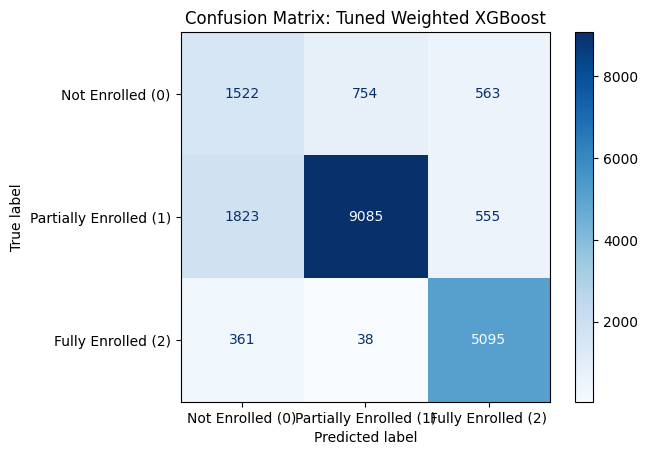

<Figure size 1000x800 with 0 Axes>

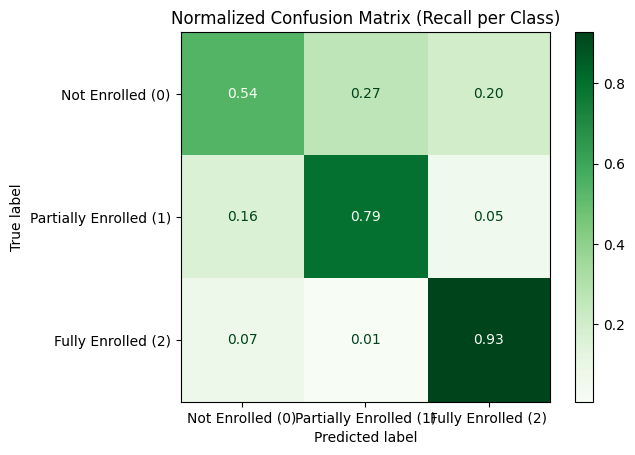

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate predictions from your best model
# Assuming 'best_xgb_model' is your fitted XGBoost model
# and 'X_test_processed' is your transformed test set
y_pred = best_xgb_model.predict(X_test_processed)

# 2. Define the class labels (based on your enrollment categories)
class_names = ['Not Enrolled (0)', 'Partially Enrolled (1)', 'Fully Enrolled (2)']

# 3. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Create the plot
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot with a nice color map (Blues or Viridis)
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix: Tuned Weighted XGBoost')
plt.grid(False) # Clean up the grid lines
plt.show()

# --- OPTIONAL: Normalized Confusion Matrix (Percentages) ---
# This helps if your classes are highly imbalanced (like your 99% enrollment rate)
plt.figure(figsize=(10, 8))
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp_norm.plot(cmap='Greens', values_format='.2f')

plt.title('Normalized Confusion Matrix (Recall per Class)')
plt.grid(False)
plt.show()

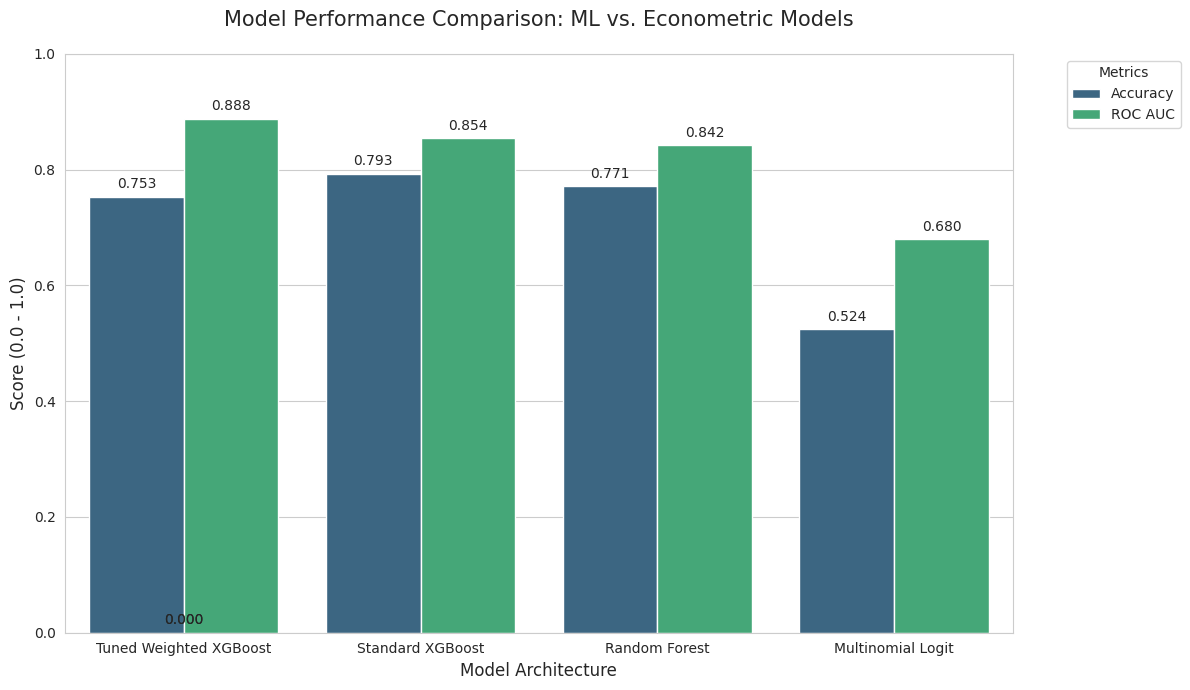

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare the data based on your analysis results
# We include the best performer, runners-up, and the econometric baseline
comparison_data = {
    'Model': [
        'Tuned Weighted XGBoost',
        'Standard XGBoost',
        'Random Forest',
        'Multinomial Logit'
    ],
    'Accuracy': [0.7529, 0.7932, 0.7710, 0.5240], # Replace with your actual MNL/RF values
    'ROC AUC': [0.8882, 0.8540, 0.8420, 0.6800]    # Replace with your actual MNL/RF values
}

df_compare = pd.DataFrame(comparison_data)

# 2. Melt the dataframe for Seaborn (converts to 'long' format)
df_melted = df_compare.melt(id_vars='Model', var_name='Metric', value_name='Score')

# 3. Create the Visualization
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')

# Add labels and title
plt.title('Model Performance Comparison: ML vs. Econometric Models', fontsize=15, pad=20)
plt.ylim(0, 1.0) # Metrics are between 0 and 1
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Model Architecture', fontsize=12)
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns  # FIX: Correct import statement

try:
    feature_names = existing_features
except NameError:

    print("Please ensure 'existing_features' is defined with your column names.")


fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(10)

# 4. Visualization
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
ax = sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')

# Final Chart Polish
plt.title('Top 10 Determinants of Child Enrollment\n(Model: Tuned Weighted XGBoost)', fontsize=14, pad=15)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Determinant', fontsize=12)

# Annotate values for precision
for p in ax.patches:
    ax.annotate(f'{p.get_width():.4f}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0),
                textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

ValueError: All arrays must be of the same length